In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("hits_lrrk2_zinc15.csv")
df

,SMILES,Score,MW,TPSA
0,CO[C@H](C)CCC(=O)N[C@]12CCC[C@H]1CN(c1cc(F)ncn...,8.563,336.41,67.35
1,CCCNc1cc(N2C[C@H]3CCC[C@@]3(c3nc(C)no3)C2)ncn1,8.387,328.42,79.97
2,CCc1nc(C)cc(N2CC[C@H]3[C@@H]2CCCN3C(=O)C2(C)CC...,8.360,328.46,49.33
3,C[C@@H](C(=O)NC[C@]1(C)CCCN(c2cc(F)ncn2)C1)c1c...,8.283,346.41,71.26
4,Cc1cc(N2CC3(CCC3)[C@H]2c2cccnc2)nc(CO)n1,8.245,296.37,62.14
...,...,...,...,...
7951,O=C(Nc1nccc(C2CC2)n1)c1cc2c(s1)CCOC2,7.000,301.37,64.11
7952,NCc1cccc(C(=O)Nc2ccc(N3CCCC3)nc2)c1,7.000,296.37,71.25
7953,Cc1nc(CNC[C@]23CCC[C@H]2CN(C(=O)[C@H]2CCCN2C)C...,7.000,346.48,77.15
7954,CC1(C(=O)N2CC[C@@]3(CCN(Cc4cc5n(n4)CCC5)C3)C2)...,7.000,342.49,41.37


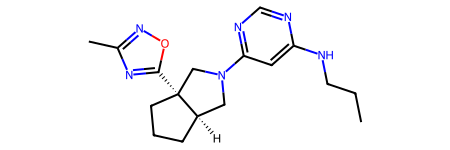

In [8]:
from rdkit import Chem

sml = df["SMILES"][1]
mol = Chem.MolFromSmiles(sml)
mol

In [9]:
sml

'CCCNc1cc(N2C[C@H]3CCC[C@@]3(c3nc(C)no3)C2)ncn1'

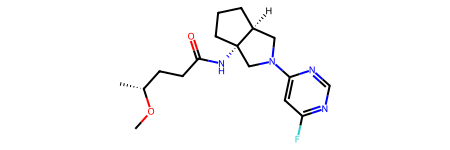

In [10]:
sml = df["SMILES"][0]
mol = Chem.MolFromSmiles(sml)
mol

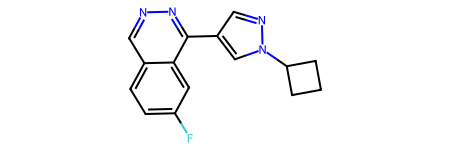

In [11]:
sml = df["SMILES"][1000]
mol = Chem.MolFromSmiles(sml)
mol

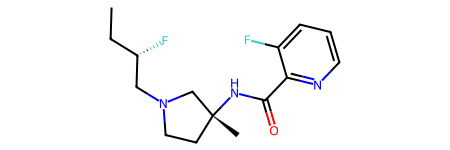

In [12]:
sml = df["SMILES"][7000]
mol = Chem.MolFromSmiles(sml)
mol

In [20]:
df["mol"] = df["SMILES"].apply(Chem.MolFromSmiles)
df["mol"]

0       <rdkit.Chem.rdchem.Mol object at 0x75279a21af80>
1       <rdkit.Chem.rdchem.Mol object at 0x75279a21a730>
2       <rdkit.Chem.rdchem.Mol object at 0x75279a21ae30>
3       <rdkit.Chem.rdchem.Mol object at 0x75279a21ab20>
4       <rdkit.Chem.rdchem.Mol object at 0x75279a21a7a0>
                              ...                       
7951    <rdkit.Chem.rdchem.Mol object at 0x75279a1051c0>
7952    <rdkit.Chem.rdchem.Mol object at 0x75279a105230>
7953    <rdkit.Chem.rdchem.Mol object at 0x75279a1052a0>
7954    <rdkit.Chem.rdchem.Mol object at 0x75279a105310>
7955    <rdkit.Chem.rdchem.Mol object at 0x75279a105380>
Name: mol, Length: 7956, dtype: object

/home/alfon/.pyenv/versions/miniconda3-latest/lib/python3.13/site-packages/rdkit/Chem/Draw/IPythonConsole.py:365: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


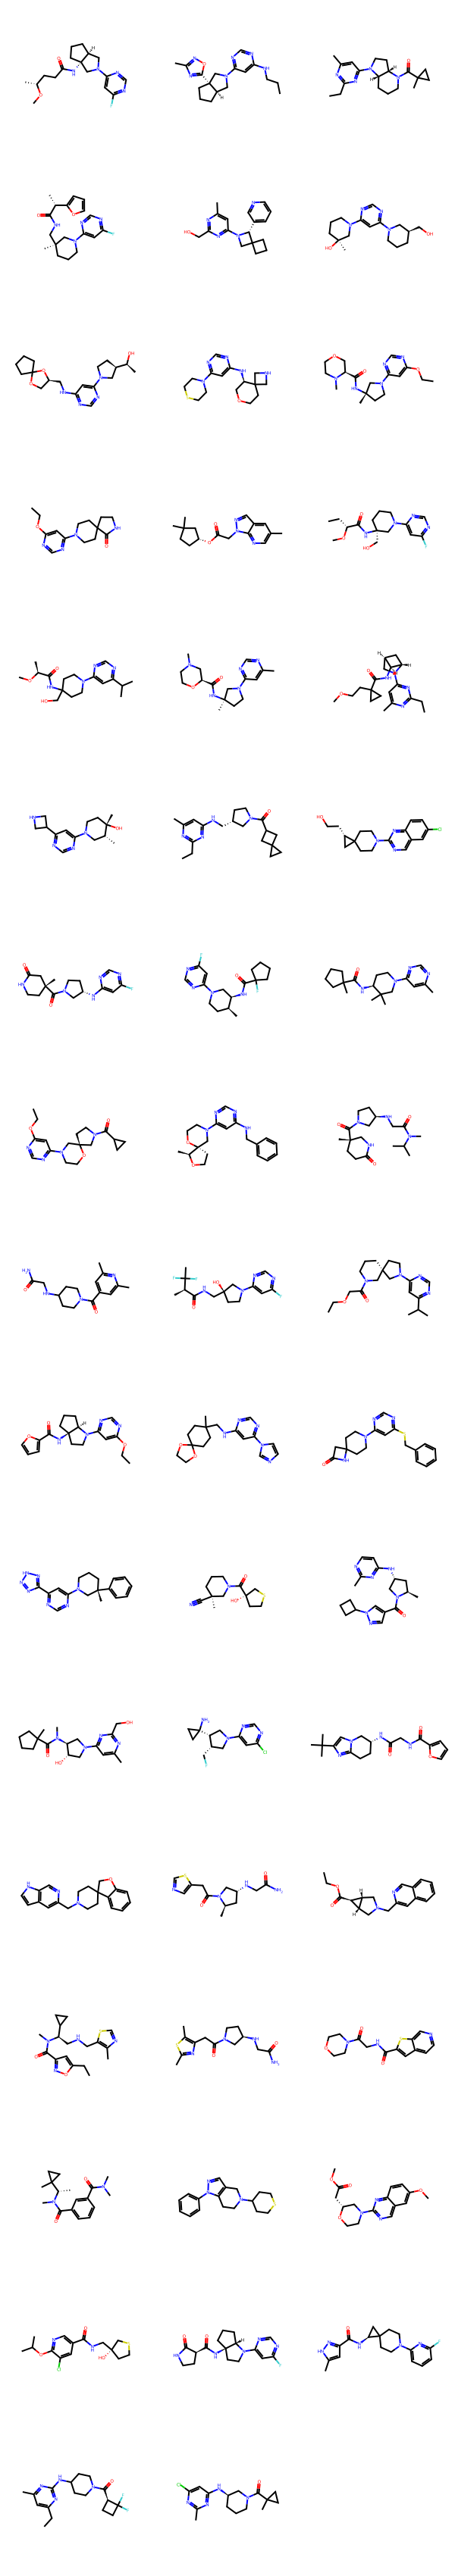

In [21]:
Chem.Draw.IPythonConsole.ShowMols(df["mol"])

In [22]:
df

,SMILES,Score,MW,TPSA,mol
0,CO[C@H](C)CCC(=O)N[C@]12CCC[C@H]1CN(c1cc(F)ncn...,8.563,336.41,67.35,<rdkit.Chem.rdchem.Mol object at 0x75279a21af80>
1,CCCNc1cc(N2C[C@H]3CCC[C@@]3(c3nc(C)no3)C2)ncn1,8.387,328.42,79.97,<rdkit.Chem.rdchem.Mol object at 0x75279a21a730>
2,CCc1nc(C)cc(N2CC[C@H]3[C@@H]2CCCN3C(=O)C2(C)CC...,8.360,328.46,49.33,<rdkit.Chem.rdchem.Mol object at 0x75279a21ae30>
3,C[C@@H](C(=O)NC[C@]1(C)CCCN(c2cc(F)ncn2)C1)c1c...,8.283,346.41,71.26,<rdkit.Chem.rdchem.Mol object at 0x75279a21ab20>
4,Cc1cc(N2CC3(CCC3)[C@H]2c2cccnc2)nc(CO)n1,8.245,296.37,62.14,<rdkit.Chem.rdchem.Mol object at 0x75279a21a7a0>
...,...,...,...,...,...
7951,O=C(Nc1nccc(C2CC2)n1)c1cc2c(s1)CCOC2,7.000,301.37,64.11,<rdkit.Chem.rdchem.Mol object at 0x75279a1051c0>
7952,NCc1cccc(C(=O)Nc2ccc(N3CCCC3)nc2)c1,7.000,296.37,71.25,<rdkit.Chem.rdchem.Mol object at 0x75279a105230>
7953,Cc1nc(CNC[C@]23CCC[C@H]2CN(C(=O)[C@H]2CCCN2C)C...,7.000,346.48,77.15,<rdkit.Chem.rdchem.Mol object at 0x75279a1052a0>
7954,CC1(C(=O)N2CC[C@@]3(CCN(Cc4cc5n(n4)CCC5)C3)C2)...,7.000,342.49,41.37,<rdkit.Chem.rdchem.Mol object at 0x75279a105310>


In [26]:
df["SMILES"][2]

'CCc1nc(C)cc(N2CC[C@H]3[C@@H]2CCCN3C(=O)C2(C)CC2)n1'

In [ ]:
import pubchempy as pcp

for sml in df["SMILES"]:
    # Buscamos en PubChem
    results = pcp.get_compounds(sml, namespace='smiles')
    
    if results:
        compound = results[0]
        print(f"Nombre común: {compound.synonyms[0] if compound.synonyms else 'No encontrado'}")
        print(f"IUPAC: {compound.iupac_name}")

In [ ]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem

for sml in df["SMILES"]:

    # 1. Definir MLi-2 (el estándar de oro para LRRK2)
    mli2_smiles = "Cc1cc(cc(c1N2CCC(CC2)Oc3cc(ccn3)C(F)(F)F)C)n4cncn4"
    mli2_mol = Chem.MolFromSmiles(mli2_smiles)
    
    # 2. Vuestro mejor candidato (SMILES que buscamos antes)
    mi_candidato_smiles = sml
    mi_candidato_mol = Chem.MolFromSmiles(mi_candidato_smiles)
    
    # 3. Generar Morgan Fingerprints para ambas (IDÉNTICOS a los del modelo)
    fp_mli2 = AllChem.GetMorganFingerprintAsBitVect(mli2_mol, 2, nBits=2048)
    fp_candidato = AllChem.GetMorganFingerprintAsBitVect(mi_candidato_mol, 2, nBits=2048)
    
    # 4. Calcular el Coeficiente de Tanimoto
    tanimoto_sim = DataStructs.TanimotoSimilarity(fp_mli2, fp_candidato)
    
    print(f"Similitud de Tanimoto entre MLi-2 y mi candidato: {tanimoto_sim:.4f}")